In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])

data = df.values.astype("float32")

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

SEQ_LENGTH = 10

X = np.array([
    data_scaled[i:i+SEQ_LENGTH]
    for i in range(len(data_scaled)-SEQ_LENGTH)
])

y = np.array([
    data_scaled[i+SEQ_LENGTH]
    for i in range(len(data_scaled)-SEQ_LENGTH)
])

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=16,
    shuffle=True
)

class BiRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 32, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class FeedforwardNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(torch.relu(self.fc1(x)))

def train_model(model, loader, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

birnn = BiRNN()
ffnn = FeedforwardNN()

train_model(birnn, train_loader)
train_model(ffnn, train_loader)

birnn.eval()
ffnn.eval()

with torch.no_grad():
    pred_birnn = birnn(X_test).numpy()
    pred_ffnn = ffnn(X_test).numpy()

actual = scaler.inverse_transform(y_test.numpy())
pred_birnn = scaler.inverse_transform(pred_birnn)
pred_ffnn = scaler.inverse_transform(pred_ffnn)

mse_birnn = mean_squared_error(actual, pred_birnn)
mse_ffnn = mean_squared_error(actual, pred_ffnn)

print("BiRNN MSE :", round(mse_birnn, 2))
print("FFNN MSE  :", round(mse_ffnn, 2))

plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual")
plt.plot(pred_birnn, label="BiRNN")
plt.plot(pred_ffnn, label="FFNN")
plt.title("BiRNN vs Feedforward NN")
plt.xlabel("Time Step")
plt.ylabel("Passengers")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'torch'

In [2]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.3/127.3 MB 2.7 MB/s  0:00:44m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 4.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.9/679.9 kB 2.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [torchvision] [torchvision]


In [1]:
import torch
print(torch.__version__)

2.14.1


BiRNN MSE : 1470.12
FFNN MSE  : 2107.34


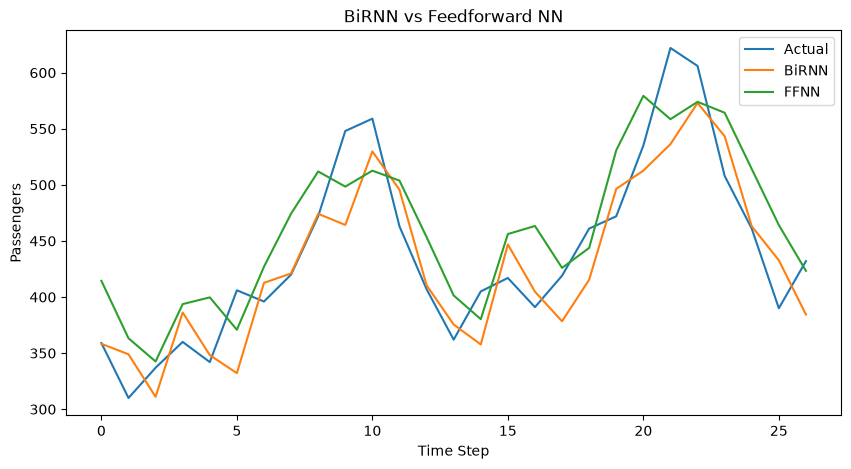

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/refs/heads/master/monthly-airline-passengers.csv"
df = pd.read_csv(url, usecols=[1])

data = df.values.astype("float32")

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

SEQ_LENGTH = 10

X = np.array([
    data_scaled[i:i+SEQ_LENGTH]
    for i in range(len(data_scaled)-SEQ_LENGTH)
])

y = np.array([
    data_scaled[i+SEQ_LENGTH]
    for i in range(len(data_scaled)-SEQ_LENGTH)
])

train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=16,
    shuffle=True
)

class BiRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(1, 32, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(64, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

class FeedforwardNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc2(torch.relu(self.fc1(x)))

def train_model(model, loader, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    for epoch in range(epochs):
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

birnn = BiRNN()
ffnn = FeedforwardNN()

train_model(birnn, train_loader)
train_model(ffnn, train_loader)

birnn.eval()
ffnn.eval()

with torch.no_grad():
    pred_birnn = birnn(X_test).numpy()
    pred_ffnn = ffnn(X_test).numpy()

actual = scaler.inverse_transform(y_test.numpy())
pred_birnn = scaler.inverse_transform(pred_birnn)
pred_ffnn = scaler.inverse_transform(pred_ffnn)

mse_birnn = mean_squared_error(actual, pred_birnn)
mse_ffnn = mean_squared_error(actual, pred_ffnn)

print("BiRNN MSE :", round(mse_birnn, 2))
print("FFNN MSE  :", round(mse_ffnn, 2))

plt.figure(figsize=(10, 5))
plt.plot(actual, label="Actual")
plt.plot(pred_birnn, label="BiRNN")
plt.plot(pred_ffnn, label="FFNN")
plt.title("BiRNN vs Feedforward NN")
plt.xlabel("Time Step")
plt.ylabel("Passengers")
plt.legend()
plt.show()